In [2]:
import numpy as np
import matplotlib.pyplot as plt

from frenel import reflection_coeff_v2, get_interpolate

In [27]:
wl = 640e-9
w0 = 450e-9
f = 1e-6
amplitude=1

k1 = 2*np.pi / wl
rp, _ = reflection_coeff_v2(wl*1e9, get_interpolate('Au'), 0)
# rp = 0
absrp = np.abs(rp)


def field(x, z):
    c_i = w0**2 - 2*1j*(z - f) / k1
    c_r = w0**2 + 2*1j*(z + f) / k1
    sqrtci = np.sqrt(c_i)
    sqrtcr = np.sqrt(c_r)

    Exi = amplitude * w0 /(k1**2 * sqrtci) * (k1**2 + 2* x**2 / c_i**2 - 1/c_i) * np.exp(-1j * k1 * (z - f) - x**2 /c_i)
    Exr = amplitude * w0 / (k1**2 * sqrtcr) * (k1**2 + 2* x**2 / c_r**2 - 1/c_r) * np.exp(1j * k1 * (z + f) - x**2 /c_r) 
    Ex =  Exi - rp*Exr

    Ezi = amplitude * 2*x*1j * w0 /k1 * 1/(c_i**1.5) * np.exp(-1j*k1*(z-f) - x**2 / c_i)
    Ezr = amplitude * 2*x*1j * w0 /k1 * 1/(c_r**1.5) * np.exp( 1j*k1*(z+f) - x**2 / c_r)
    Ez = Ezi + rp*Ezr

    return Exi, Exr, Ezi, Ezr


def ExiEzi(x, z):
    c_i = w0**2 - 2*1j*(z - f) / k1
    c_r = w0**2 + 2*1j*(z + f) / k1
    sqrtci = np.sqrt(c_i)
    sqrtcr = np.sqrt(c_r)

    Exi = amplitude * w0 /(k1**2 * sqrtci) * (k1**2 + 2* x**2 / c_i**2 - 1/c_i) * np.exp(-1j * k1 * (z - f) - x**2 /c_i)
    Ezi = amplitude * 2*x*1j * w0 /k1 * 1/(c_i**1.5) * np.exp(-1j*k1*(z-f) - x**2 / c_i)

    return np.imag(Exi*np.conj(Ezi))


def ExiEzr(x, z):
    c_i = w0**2 - 2*1j*(z - f) / k1
    c_r = w0**2 + 2*1j*(z + f) / k1
    sqrtci = np.sqrt(c_i)
    sqrtcr = np.sqrt(c_r)

    Exi = amplitude * w0 /(k1**2 * sqrtci) * (k1**2 + 2* x**2 / c_i**2 - 1/c_i) * np.exp(-1j * k1 * (z - f) - x**2 /c_i)
    Ezr = amplitude * 2*x*1j * w0 /k1 * 1/(c_r**1.5) * np.exp( 1j*k1*(z+f) - x**2 / c_r)
    return np.imag(np.conj(rp) * Exi * np.conj(Ezr))


def ExrEzi(x, z):
    c_i = w0**2 - 2*1j*(z - f) / k1
    c_r = w0**2 + 2*1j*(z + f) / k1
    sqrtci = np.sqrt(c_i)
    sqrtcr = np.sqrt(c_r)

    Exr = amplitude * w0 / (k1**2 * sqrtcr) * (k1**2 + 2* x**2 / c_r**2 - 1/c_r) * np.exp(1j * k1 * (z + f) - x**2 /c_r) 
    Ezi = amplitude * 2*x*1j * w0 /k1 * 1/(c_i**1.5) * np.exp(-1j*k1*(z-f) - x**2 / c_i)
    
    return np.imag(rp * Exr*np.conj(Ezi))


def ExrEzr(x, z):
    c_i = w0**2 - 2*1j*(z - f) / k1
    c_r = w0**2 + 2*1j*(z + f) / k1
    sqrtci = np.sqrt(c_i)
    sqrtcr = np.sqrt(c_r)

    Exr = amplitude * w0 / (k1**2 * sqrtcr) * (k1**2 + 2* x**2 / c_r**2 - 1/c_r) * np.exp(1j * k1 * (z + f) - x**2 /c_r) 
    Ezr = amplitude * 2*x*1j * w0 /k1 * 1/(c_r**1.5) * np.exp( 1j*k1*(z+f) - x**2 / c_r)
    return absrp**2*np.imag(Exr*np.conj(Ezr))


In [4]:
eps2 = get_interpolate('Au')(wl*1e9)
k2 = 2*np.pi / wl * np.sqrt(eps2 + 0j)

zeta = np.sqrt((eps2**2 * k1**2 - k2**2) /(eps2**2 - 1))

def dxGxz(x, z):
    b = k1**2 - zeta**2
    s = np.sqrt(b)
    e = np.exp(-2*1j*z*s)
    return np.imag(eps2**2 * b * zeta**2 / (2*k1**2 * (eps2**2 - 1)) * e)

In [52]:
nx, nz = 400, 400

a = 2
b = 3
xmesh = np.linspace(-a*wl, a*wl, nx)
zmesh = f+np.linspace(-b*wl, b*wl, nz)

vals = np.zeros((nz, nx))
for i in range(nx):
    for j in range(nz):
        x0, z0 = xmesh[i], zmesh[j]
        ii = ExiEzi(x0, z0)
        ir = ExiEzr(x0, z0)
        ri = ExrEzi(x0, z0)
        rr = ExrEzr(x0, z0)
        tot = ii + ir - ri - rr
        # dG = dxGxz(x0, z0)
        
        vals[j, i] = ir-ri

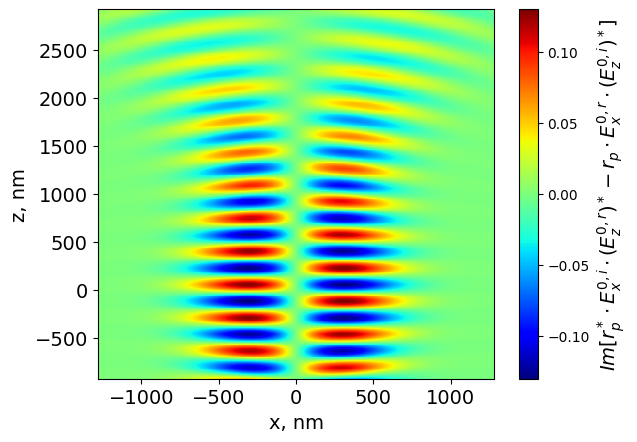

In [53]:
fig, ax = plt.subplots()
cmesh = ax.pcolormesh(1e9*xmesh, 1e9*zmesh, vals, cmap='jet')
cbar = plt.colorbar(cmesh, ax=ax)

# Im [ E_x^{0,i}\\cdot(E_z^{0,i})^*]
# -|r_p|^2 \\cdot Im [ E_x^{0,r}\\cdot(E_z^{0,r})^*]
# Im [r_p^* \\cdot E_x^{0,i}\\cdot(E_z^{0,r})^* - r_p \\cdot E_x^{0, r} \\cdot (E_z^{0, i})^*]

cbar.set_label('$Im [r_p^* \\cdot E_x^{0,i}\\cdot(E_z^{0,r})^* - r_p \\cdot E_x^{0, r} \\cdot (E_z^{0, i})^*]$', fontsize=14)
ax.set_xlabel('x, nm', fontsize=14)
ax.set_ylabel('z, nm', fontsize=14)
ax.tick_params(axis='both', labelsize=14)
plt.savefig('/home/uspensky/Изображения/fields_prod_plots/ir-ri_wl_extended.png', dpi=200)

### 1/c_{i, r} - 1/c_{r, i}^*

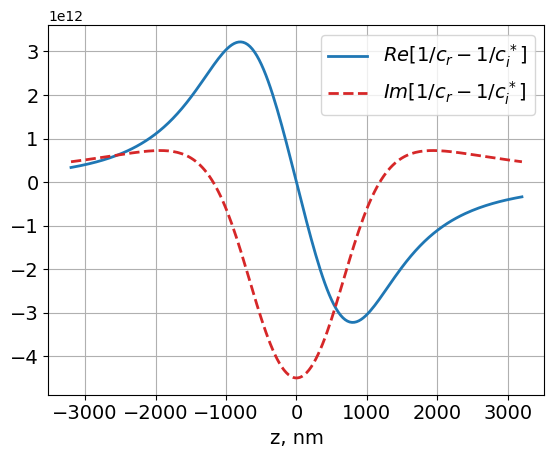

In [40]:
zmesh = np.linspace(-5*wl, 5*wl, 200)
Ci_Crcc = np.zeros_like(zmesh, dtype=np.complex64)
Cr_Cicc = np.zeros_like(zmesh, dtype=np.complex64)

for j in range(len(zmesh)):
    Ci_Crcc[j] = 1 / c_i(zmesh[j]) - 1 / np.conj(c_r(zmesh[j]))
    Cr_Cicc[j] = 1 / c_r(zmesh[j]) - 1 / np.conj(c_i(zmesh[j]))

# plt.plot(1e9*zmesh, np.real(Ci_Crcc), label='$Re [1/c_i - 1/c_r^*]$', lw=2)
# plt.plot(1e9*zmesh, np.imag(Ci_Crcc), label='$Im [1/c_i - 1/c_r^*]$', linestyle='--', lw=2, c='tab:red')

plt.plot(1e9*zmesh, np.real(Cr_Cicc), label='$Re [1/c_r - 1/c_i^*]$', lw=2)
plt.plot(1e9*zmesh, np.imag(Cr_Cicc), label='$Im [1/c_r - 1/c_i^*]$', linestyle='--', lw=2, c='tab:red')
plt.xlabel('z, nm', fontsize=14)
plt.grid()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.savefig('/home/uspensky/Изображения/invcr-invcicc.png', dpi=200)